In [1]:
from pathlib import Path
# import sys  # Uncomment with the project-metrics block below.

from IPython.display import display
import gerrychain
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

relative_csv = Path("outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_poc.csv")

for candidate_root in [Path.cwd(), *Path.cwd().parents]:
    if (candidate_root / relative_csv).exists() and (
        candidate_root / "pipeline" / "calculate_metrics.py"
    ).exists():
        project_root = candidate_root
        break
else:
    raise FileNotFoundError(f"Could not find {relative_csv} from {Path.cwd()}")

csv_path = project_root / relative_csv


df = pd.read_csv(csv_path)

## Plot the tract share variance (~Moran's denominator) observed in yearly data

Loaded 500 graph JSONs...
Loaded 1,000 graph JSONs...
Loaded 1,500 graph JSONs...


,year,mean_moran_denominator,median_moran_denominator,mean_tract_share_variance,median_tract_share_variance,n_areas
0,1980,8.017179,1.077613,0.037584,0.029633,379
1,1990,8.912634,1.367958,0.037015,0.030546,384
2,2000,9.657616,1.487406,0.037768,0.033228,392
3,2010,9.989301,1.651874,0.037192,0.032811,392
4,2020,9.748557,1.787934,0.033847,0.030472,392


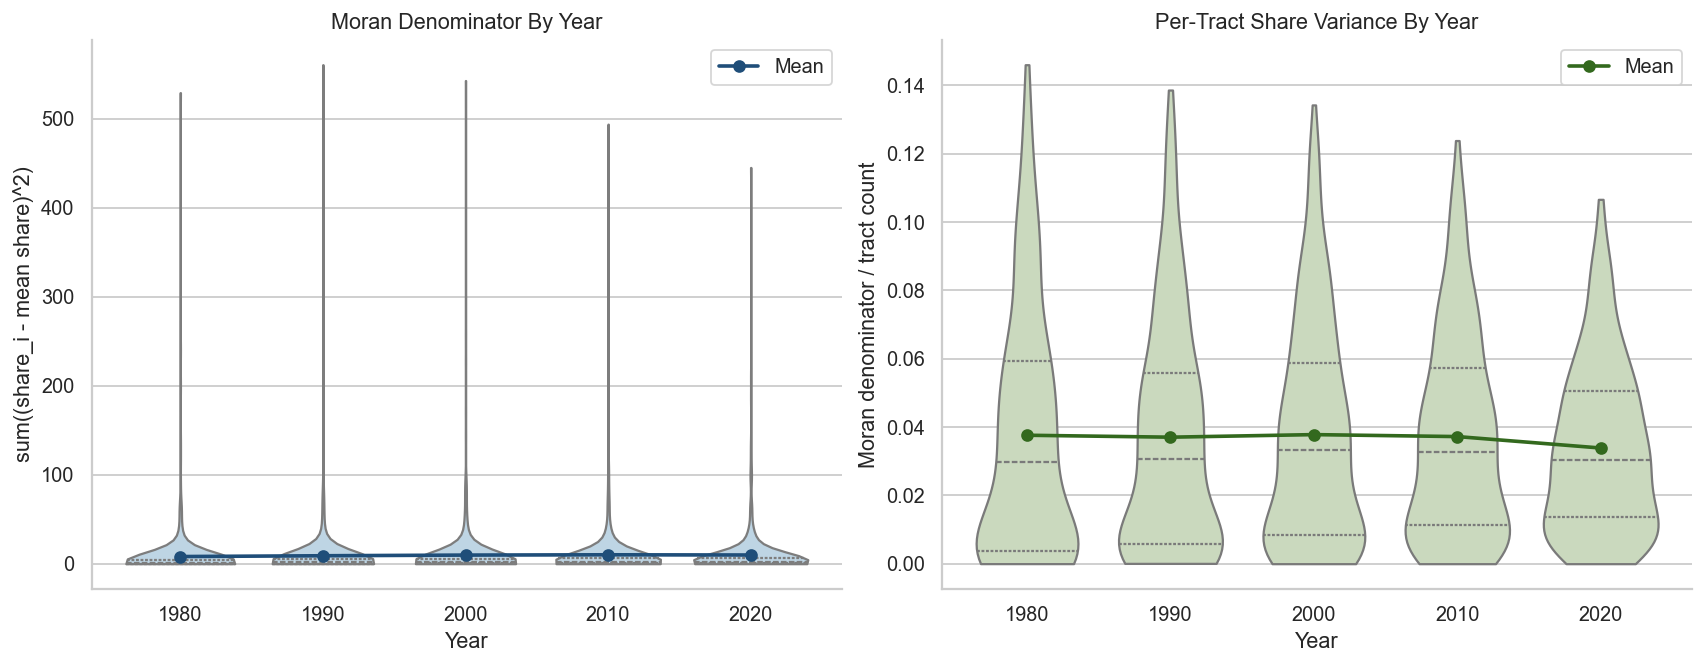

In [ ]:
df = df.copy()
df["year"] = df["filename"].str.extract(r"/(\d{4})/")[0].astype(int)
df["cbsa"] = df["filename"].str.extract(r"cbsa_(\d+)_")[0]

year_order = sorted(df["year"].unique())
year_categories = [str(year) for year in year_order]

denominator_records = []

for row_number, area in enumerate(df.itertuples(index=False), start=1):
    graph = gerrychain.Graph.from_json(project_root / area.filename)
    shares = []

    for node in graph.nodes():
        x_pop = int(graph.nodes[node][area.x_col])
        y_pop = int(graph.nodes[node][area.y_col])
        node_total = x_pop + y_pop
        if node_total > 0:
            shares.append(x_pop / node_total)

    shares = np.array(shares, dtype=float)
    mean_share = shares.mean()
    moran_denominator = float(np.sum((shares - mean_share) ** 2))

    denominator_records.append(
        {
            "filename": area.filename,
            "year": area.year,
            "cbsa": area.cbsa,
            "moran_denominator": moran_denominator,
            "tract_share_variance": moran_denominator / len(shares),
            "mean_share": mean_share,
            "n_tracts_with_population": len(shares),
        }
    )

    if row_number % 500 == 0:
        print(f"Loaded {row_number:,} graph JSONs...")

denominators = pd.DataFrame(denominator_records)
denominators["year_label"] = pd.Categorical(
    denominators["year"].astype(str),
    categories=year_categories,
    ordered=True,
)

yearly_summary = (
    denominators.groupby("year", as_index=False)
    .agg(
        mean_moran_denominator=("moran_denominator", "mean"),
        median_moran_denominator=("moran_denominator", "median"),
        mean_tract_share_variance=("tract_share_variance", "mean"),
        median_tract_share_variance=("tract_share_variance", "median"),
        n_areas=("filename", "size"),
    )
)
display(yearly_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.violinplot(
    data=denominators,
    x="year_label",
    y="moran_denominator",
    inner="quartile",
    cut=0,
    color="#B8D7EA",
    ax=axes[0],
)
axes[0].plot(
    range(len(year_order)),
    yearly_summary["mean_moran_denominator"],
    marker="o",
    color="#1F4E79",
    linewidth=2,
    label="Mean",
)
axes[0].set_title("Moran Denominator By Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("sum((share_i - mean share)^2)")
axes[0].legend()

sns.violinplot(
    data=denominators,
    x="year_label",
    y="tract_share_variance",
    inner="quartile",
    cut=0,
    color="#C9DDBA",
    ax=axes[1],
)
axes[1].plot(
    range(len(year_order)),
    yearly_summary["mean_tract_share_variance"],
    marker="o",
    color="#33691E",
    linewidth=2,
    label="Mean",
)
axes[1].set_title("Per-Tract Share Variance By Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Moran denominator / tract count")
axes[1].legend()

plt.show()

the amount of Black-share variation across tracts is not changing much.

So the upward trend seen in Moran has to be coming from the nominator, the neighbor covariance of minority shares. Existing high-share and low-share areas are becoming smoother, so Moran rises. Why doesn't Capy pick that up?